# Exercises

In [16]:
import pickle
import numpy as np
import ipywidgets as widgets
from ipywidgets import interact
import matplotlib.pyplot as plt
from tqdm import tqdm
import seaborn as sns
from scipy.stats import pearsonr
import sys
import os
sys.path.append(os.path.abspath("code"))
from utils import download_data

sns.set_theme(context='notebook',style='white',font_scale=1.5,
              rc = {'axes.spines.top':False,'axes.spines.right':False})

## Exercise 1
---

You can find below the code that was used to generate the activity of place cells on a linear track.
Use the code and the decoding procedure you lerned about in the lesson to explore how different features of the data impact our ability to decode position.
In particular:

A - Try to use different fractions of our data samples. How does the median error change when the the number of available sample gets larger? You do not need to re-generate any data, just randomly sub-sample the data to different fractions.

B - How many place cells do we need to reliably decode position? Try to re-do the decoding using only 10 cell, then 20, and so on. How does the median error change? Does it reach an asymptote? (Also in this case, you do not need to re-generate the data, you can just select a random subset of cells each time)

C - Generate new data using the code below, changing the firing rate noise (changing the value of the variable `noise firing_rate`). How does this noise impact the decoding? 

Exercise A

In [3]:
#download lesson data
download_data('https://surfdrive.surf.nl/files/index.php/s/TliAW2xObyy0keu')

In [4]:
#code: data import
data_file = 'data/linear_track_data.pickle'
with open(data_file, 'rb') as handle:
    data = pickle.load(handle)

x,t,spikes = data['x'],data['t'],data['spikes']
track_length = data['track_length']
fps = data['fps'] 
n_cells = len(spikes)

In [ ]:
def plot_unit(i):
    plt.plot(t, x)
    plt.plot(spikes[i], np.interp(spikes[i], t, x), 'r.')
    
interact(plot_unit, i = widgets.IntSlider(min=0, max=(n_cells-1), value=0));

interactive(children=(IntSlider(value=0, description='i', max=99), Output()), _dom_classes=('widget-interact',…

In [6]:
# we compute the poistion at which each spike was emitted
spike_positions = [np.interp(s, t, x) for s in spikes]
space_bins = np.arange(0., track_length, 5.) # binning in bins of 5 cms

# we compute histograms for each cell
spikes_hist= [np.histogram(s, space_bins)[0] for s in spike_positions]
spikes_hist = np.asarray(spikes_hist)

# we also need an "occupancy histogram" in order to normalize the firing rates maps 
occupancy = np.histogram(x, space_bins)[0] /  fps

firing_rate_maps = spikes_hist / occupancy 

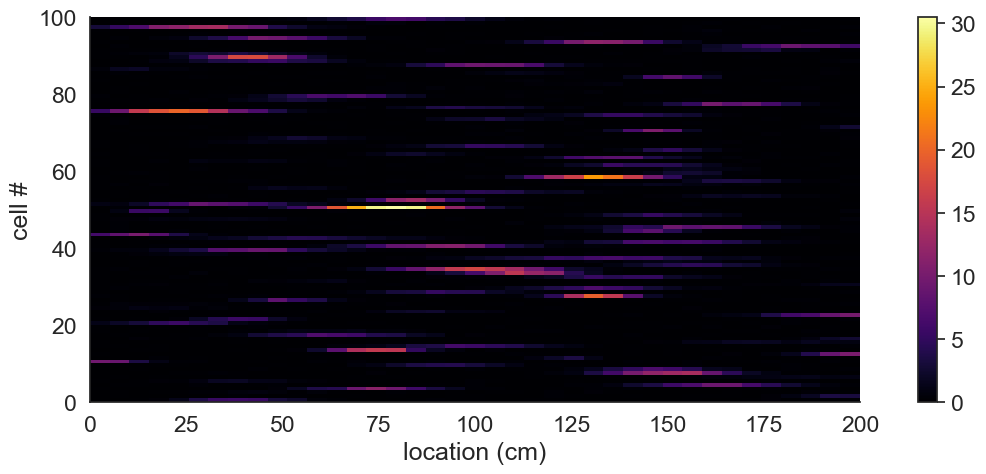

In [7]:
# let's look at the ratemaps
plt.figure(figsize=(15,5))
plt.imshow(firing_rate_maps, cmap='inferno', extent = [0, 200, 0, n_cells])
plt.xlabel('location (cm)')
plt.ylabel('cell #')
plt.colorbar()

In [8]:
spikes_count= [np.histogram(s,t)[0] for s in spikes]
spikes_count = np.asarray(spikes_count).T # we transpose the matrix to have the more familiar (samples x features) shape

In [9]:
# code decoding
from scipy.stats import poisson

true_x = x[:-1] # get rid of last timepoint to have same length as binned spikes
decoding_times = t[:-1]

x_decoded = np.zeros_like(true_x)

for t_bin in tqdm(range(len(decoding_times))):
    if sum(spikes_count[t_bin,:])>0: # Check if the time window contains spikes
        posterior = np.empty(firing_rate_maps.shape[-1])

        for i in range(len(posterior)):
            # Note that we work with log so that we can sum probabilities
            # instead of multiplying them 
            #posterior[i] = sum(np.log(poisson.pmf(spikes_count[t_bin,:],firing_rate_maps[:,i]/fps)+pow(1,-15)))
            posterior[i] = sum(poisson.logpmf(spikes_count[t_bin,:],firing_rate_maps[:,i]/fps)+pow(10,-15))


        x_decoded[t_bin] = space_bins[np.argmax(posterior)]
    else:
        x_decoded[t_bin] = np.nan   


100%|██████████| 5026/5026 [00:14<00:00, 357.37it/s]


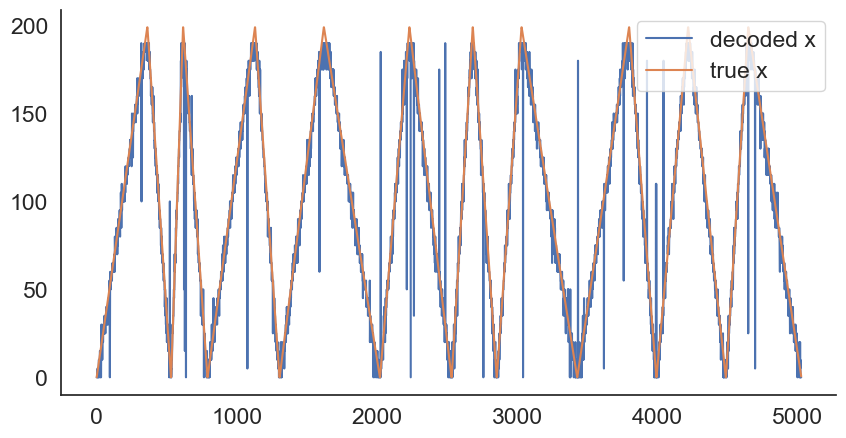

In [10]:
plt.figure(figsize=(10,5))
plt.plot(x_decoded,label= 'decoded x')
plt.plot(true_x,label = 'true x')
plt.legend()

Median error: 3.357155002380459 cm


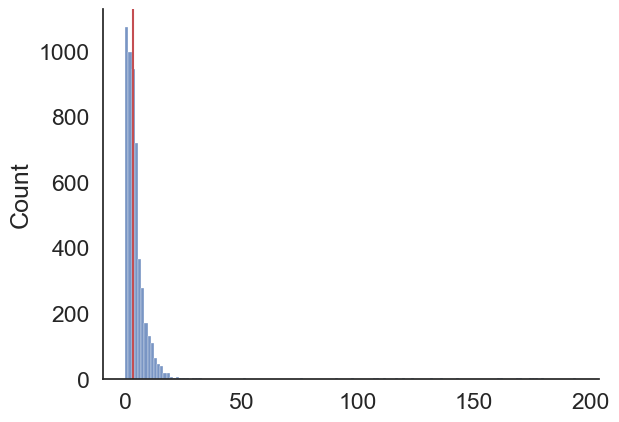

In [11]:
# error distribution
mse = np.sqrt((true_x-x_decoded)**2)
sns.histplot(mse)
plt.axvline(x = np.nanmedian(mse),c='r')
print(f'Median error: {np.nanmedian(mse)} cm')

Subsampling randomly at different fractions from the full dataset, and rerunning the simulation

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import poisson
from tqdm import tqdm

fractions = [0.05, 0.1, 0.2, 0.4, 0.6, 0.8, 1.0]
n_repeats = 5

median_errors = []

for frac in fractions:
    print(f"now re-running the decoding loop for {frac*100}% of the total amount of available samples")

    frac_errors = []

    for rep in range(n_repeats):
        print(f"starting realisation nr {rep+1}")
        # -----------------------------
        # Randomly subsample time points
        # -----------------------------
        n_keep = int(frac * len(x))
        idx = np.sort(np.random.choice(len(x), size=n_keep, replace=False))

        x_sub = x[idx]
        t_sub = t[idx]

        # ---------------------------------------
        # Recompute spike positions for each cell
        # ---------------------------------------
        spike_positions_sub = [np.interp(s, t_sub, x_sub) for s in spikes]

        # ---------------------------------------
        # Recompute occupancy
        # ---------------------------------------
        occupancy_sub = np.histogram(x_sub, space_bins)[0] / fps
        occupancy_sub[occupancy_sub == 0] = np.nan

        # ---------------------------------------
        # Recompute place fields
        # ---------------------------------------
        spikes_hist_sub = [np.histogram(pos, space_bins)[0] for pos in spike_positions_sub]
        spikes_hist_sub = np.asarray(spikes_hist_sub)

        firing_rate_maps_sub = (spikes_hist_sub / occupancy_sub)
        firing_rate_maps_sub = np.nan_to_num(firing_rate_maps_sub)

        # ---------------------------------------
        # Recompute spike counts
        # ---------------------------------------
        spikes_count_sub = [np.histogram(s, t_sub)[0] for s in spikes]

        spikes_count_sub = np.asarray(spikes_count_sub).T

        true_x_sub = x_sub[:-1]
        decoding_times_sub = t_sub[:-1]

        x_decoded = np.full_like(true_x_sub, np.nan)

        # ---------------------------------------
        # Decode
        # ---------------------------------------
        for t_bin in range(len(decoding_times_sub)):

            if np.sum(spikes_count_sub[t_bin, :]) > 0:

                posterior = np.empty(
                    firing_rate_maps_sub.shape[1]
                )

                for i in range(len(posterior)):

                    posterior[i] = np.sum(poisson.logpmf(spikes_count_sub[t_bin, :],firing_rate_maps_sub[:, i] / fps))

                x_decoded[t_bin] = space_bins[np.argmax(posterior)]

        # ---------------------------------------
        # Error
        # ---------------------------------------
        error = np.abs(true_x_sub - x_decoded)

        frac_errors.append(np.nanmedian(error))

    median_errors.append(np.mean(frac_errors))

now re-running the decoding loop for 5.0% of the total amount of available samples
starting realisation nr 1
starting realisation nr 2
starting realisation nr 3
starting realisation nr 4
starting realisation nr 5
now re-running the decoding loop for 10.0% of the total amount of available samples
starting realisation nr 1
starting realisation nr 2
starting realisation nr 3
starting realisation nr 4
starting realisation nr 5
now re-running the decoding loop for 20.0% of the total amount of available samples
starting realisation nr 1
starting realisation nr 2
starting realisation nr 3
starting realisation nr 4
starting realisation nr 5
now re-running the decoding loop for 40.0% of the total amount of available samples
starting realisation nr 1
starting realisation nr 2
starting realisation nr 3
starting realisation nr 4
starting realisation nr 5
now re-running the decoding loop for 60.0% of the total amount of available samples
starting realisation nr 1
starting realisation nr 2
starting 

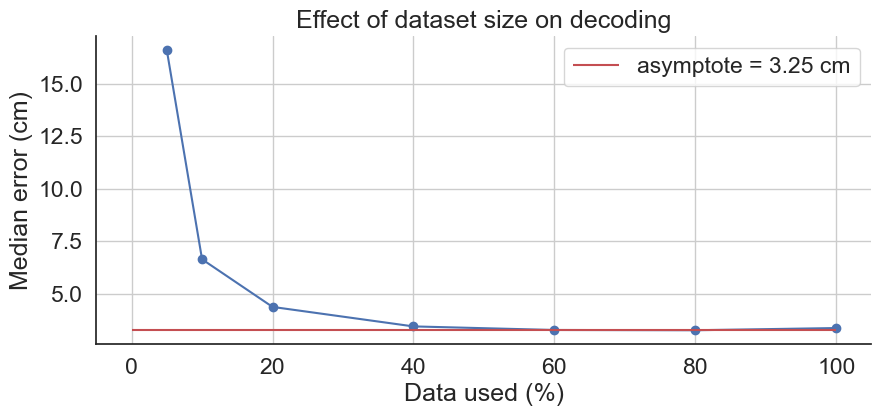

In [34]:
plt.figure(figsize=(10,4))
plt.plot(
    np.array(fractions)*100,
    median_errors,
    'o-'
)
plt.xlabel('Data used (%)')
plt.ylabel('Median error (cm)')
plt.hlines(y= np.min(median_errors), xmin = 0, xmax = 100, label= f'asymptote = {np.round(a=np.min(median_errors), decimals = 2)} cm', colors= 'r')
plt.title('Effect of dataset size on decoding')
plt.legend()
plt.grid()


As can be seen very clearly, the average median error asymptotes at 3.25 cm when we use approximately 60% of the samples present in the dataset. This is useful to know in case we want to save time in future simulations and it gives an insight into how much of the recording is redundant. I.e. this essentially says that we could also have used a tracklength that was 60% of the lenght of the one that was originally used or we could have used a lower sampling rate to obtain the same accuracy

Exercise B

In [40]:
from scipy.stats import poisson
import numpy as np
import matplotlib.pyplot as plt

cell_numbers = np.arange(10, n_cells + 1, 20)
n_repeats = 5

median_errors = []

true_x = x[:-1]
decoding_times = t[:-1]

for n_selected in cell_numbers:
    print(f"now re-running the decoding loop for {n_selected} cells")
    errors_this_size = []

    for rep in range(n_repeats):
        print(f"starting realisation nr {rep+1} ")
        # Randomly choose cells
        selected_cells = np.random.choice(
            n_cells,
            size=n_selected,
            replace=False
        )

        fr_maps_sub = firing_rate_maps[selected_cells, :]
        spikes_sub = spikes_count[:, selected_cells]

        x_decoded = np.full_like(true_x, np.nan)

        # Decode
        for t_bin in range(len(decoding_times)):

            if np.sum(spikes_sub[t_bin, :]) > 0:

                posterior = np.empty(fr_maps_sub.shape[1])

                for i in range(len(posterior)):

                    posterior[i] = np.sum(
                        poisson.logpmf(
                            spikes_sub[t_bin, :],
                            fr_maps_sub[:, i] / fps
                        )
                    )

                x_decoded[t_bin] = space_bins[
                    np.argmax(posterior)
                ]

        error = np.abs(true_x - x_decoded)

        errors_this_size.append(
            np.nanmedian(error)
        )

    median_errors.append(
        np.mean(errors_this_size)
    )

now re-running the decoding loop for 10 cells
starting realisation nr 1 
starting realisation nr 2 
starting realisation nr 3 
starting realisation nr 4 
starting realisation nr 5 
now re-running the decoding loop for 30 cells
starting realisation nr 1 
starting realisation nr 2 
starting realisation nr 3 
starting realisation nr 4 
starting realisation nr 5 
now re-running the decoding loop for 50 cells
starting realisation nr 1 
starting realisation nr 2 
starting realisation nr 3 
starting realisation nr 4 
starting realisation nr 5 
now re-running the decoding loop for 70 cells
starting realisation nr 1 
starting realisation nr 2 
starting realisation nr 3 
starting realisation nr 4 
starting realisation nr 5 
now re-running the decoding loop for 90 cells
starting realisation nr 1 
starting realisation nr 2 
starting realisation nr 3 
starting realisation nr 4 
starting realisation nr 5 


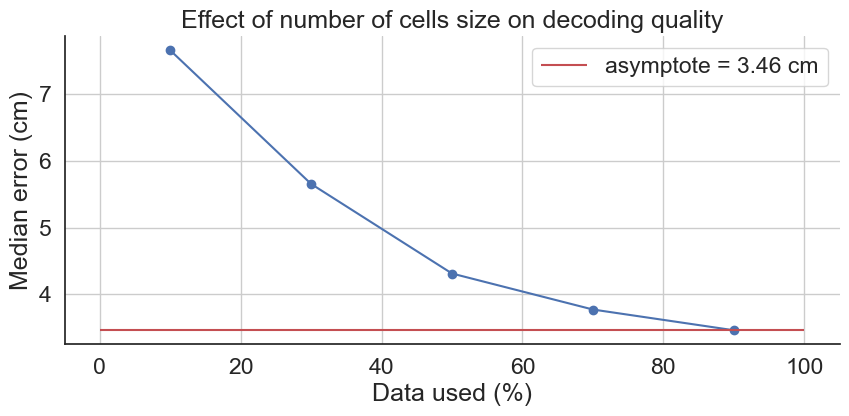

In [41]:
plt.figure(figsize=(10,4))
plt.plot(
    cell_numbers,
    median_errors,
    'o-'
)
plt.xlabel('Data used (%)')
plt.ylabel('Median error (cm)')
plt.hlines(y= np.min(median_errors), xmin = 0, xmax = 100, label= f'asymptote = {np.round(a=np.min(median_errors), decimals = 2)} cm', colors= 'r')
plt.title('Effect of number of cells size on decoding quality')
plt.legend()
plt.grid()


No true asymptote is reached, the results do make sense as it looks like the smallest error achievable seems about to match that of the previous exercise when using 100 cells. 

Exercise C

In [48]:
import numpy as np
import scipy
import scipy.stats
import scipy.io
import matplotlib
import matplotlib.pyplot as plt

%matplotlib inline 
plt.rcParams['figure.figsize'] = [10, 5]
from ipywidgets import interact
import ipywidgets as widgets


track_length = 200. # the length of our linear track (eg in centimeter)
average_firing_rate = 5 # the peak firing rate, averaged across the population 
n_cells = 100 # how many cells we are recording
pf_centers = np.random.rand(n_cells) * track_length # the centers of the place fields for all cells drawn randomly with a uniform distribution on the track
pf_size = np.random.gamma(10, size=n_cells) # the size (width) of the place fields, drawn randomly from a gamma distribution 
pf_rate = np.random.exponential(scale=average_firing_rate, size=n_cells) # the peak firing rate for each cell, drawn from an exponential distribution
bins = np.arange(0., 200.)
true_firing_rate_maps = np.zeros((n_cells, len(bins)))
for i in range(n_cells):
    true_firing_rate_maps[i,:] = pf_rate[i] * np.exp(-((bins-pf_centers[i])**2)/(2*pf_size[i]**2))
# GENERATE TRAJECTORY

n_runs = 10
use_stops = False
av_running_speed = 10 # the average running speed (in cm/s)
fps = 10 # the number of "video frames" per second 
running_speed_a = np.random.chisquare(10, size=n_runs) # running speed in the two directions
running_speed_b = np.random.chisquare(10, size=n_runs) 

stopping_time_a = np.random.chisquare(15, size=n_runs) # the time the mouse will spend at the two ends of the track
stopping_time_b = np.random.chisquare(15, size=n_runs)

x = np.array([])


for i in range(n_runs):
    stop1 = np.ones((int(stopping_time_a[i]*fps),)) * 0.
    run_length = len(bins) * fps / running_speed_a[i]
    run1 = np.linspace(0., float(len(bins)-1), int(run_length))
    stop2 = np.ones((int(stopping_time_b[i]*fps),)) * (len(bins)-1.)
    run_length = len(bins) * fps / running_speed_b[i]
    run2 = np.linspace(len(bins)-1., 0., int(run_length))
    if use_stops:
        x = np.concatenate((x, stop1, run1, stop2, run2))
    else:
         x = np.concatenate((x, run1, run2))
t = np.arange(len(x))/fps
sampling_rate = 10000.
t_sampling = np.arange(0, t[-1], 1. / sampling_rate)
x_sampling = np.floor(np.interp(t_sampling, t, x))

In [49]:
from scipy.stats import poisson

noise_levels = [0.01, 0.1, 0.5, 1.0, 2.0]
median_errors = []

for noise_firing_rate in noise_levels:

    print(f"Running noise level = {noise_firing_rate}")

    # ==================================================
    # Generate spikes with current noise level
    # ==================================================
    spikes = []

    for cell in range(n_cells):

        inst_rate = (
            true_firing_rate_maps[cell, x_sampling.astype(np.int32)]
            + noise_firing_rate
        )

        spikes_loc = np.random.poisson(
            inst_rate / sampling_rate
        )

        sp = np.argwhere(spikes_loc).flatten()

        t_sp = t_sampling[sp]

        spikes.append(t_sp)

    # ==================================================
    # Build firing-rate maps (same as original notebook)
    # ==================================================
    spike_positions = [
        np.interp(s, t, x)
        for s in spikes
    ]

    spikes_hist = [
        np.histogram(s, space_bins)[0]
        for s in spike_positions
    ]

    spikes_hist = np.asarray(spikes_hist)

    occupancy = (
        np.histogram(x, space_bins)[0] / fps
    )

    occupancy[occupancy == 0] = np.nan

    firing_rate_maps = (
        spikes_hist / occupancy
    )

    firing_rate_maps = np.nan_to_num(
        firing_rate_maps
    )

    # ==================================================
    # Compute spike counts
    # ==================================================
    spikes_count = [
        np.histogram(s, t)[0]
        for s in spikes
    ]

    spikes_count = np.asarray(
        spikes_count
    ).T

    # ==================================================
    # Decode position
    # ==================================================
    true_x = x[:-1]
    decoding_times = t[:-1]

    x_decoded = np.full_like(
        true_x,
        np.nan
    )

    for t_bin in range(len(decoding_times)):

        if np.sum(spikes_count[t_bin, :]) > 0:

            posterior = np.empty(
                firing_rate_maps.shape[1]
            )

            for i in range(len(posterior)):

                posterior[i] = np.sum(
                    poisson.logpmf(
                        spikes_count[t_bin, :],
                        firing_rate_maps[:, i] / fps
                    )
                )

            x_decoded[t_bin] = space_bins[
                np.argmax(posterior)
            ]

    # ==================================================
    # Compute error
    # ==================================================
    error = np.abs(
        true_x - x_decoded
    )

    median_error = np.nanmedian(error)

    median_errors.append(
        median_error
    )

    print(
        f"Median error = {median_error:.2f} cm"
    )

Running noise level = 0.01
Median error = 3.45 cm
Running noise level = 0.1
Median error = 3.46 cm
Running noise level = 0.5
Median error = 3.71 cm
Running noise level = 1.0
Median error = 4.01 cm
Running noise level = 2.0
Median error = 4.47 cm


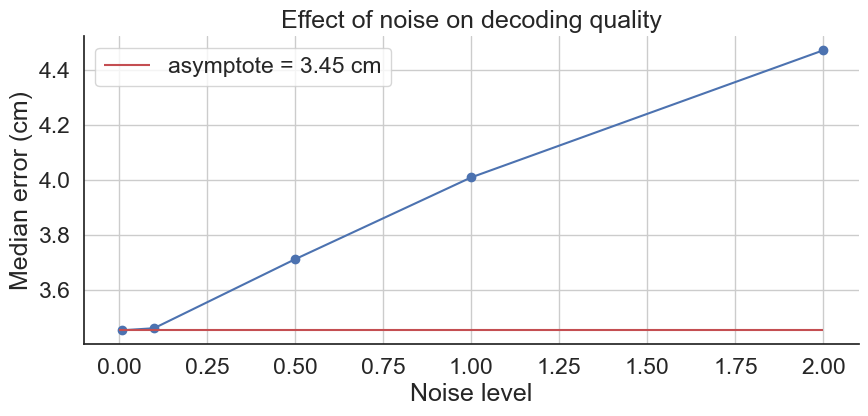

In [52]:
plt.figure(figsize=(10,4))
plt.plot(
    noise_levels,
    median_errors,
    'o-'
)
plt.xlabel('Noise level')
plt.ylabel('Median error (cm)')
plt.hlines(y= np.min(median_errors), xmin = 0, xmax = 2, label= f'asymptote = {np.round(a=np.min(median_errors), decimals = 2)} cm', colors= 'r')
plt.title('Effect of noise on decoding quality')
plt.legend()
plt.grid()


Increasing the noise level makes the median error greater. This effect asymptotes from below at a median error of 3.45 cm for roughly 0.1 as a noise level

## Exercise 2
---
In the loop implementation of the decoder, we used `poisson.logpmf(k,mu)` to calculate the log probability of observing $k$ spikes given an average firing rate of $\mu$. 
This is mathematically equivalent to `np.log(poisson.pmf(k,mu))`, in which we calculate the probability, and then take the log.


Re-run the decoding substituting this expression:

```
posterior[i] = sum(np.log(poisson.pmf(spikes_count[t_bin,:],firing_rate_maps[:,i]/fps)+pow(1,-15)))
```

To the line we are using to calculate the posterior.
Do you see any difference in the results? What do you think this is due to?




In [53]:
#code: data import
data_file = 'data/linear_track_data.pickle'
with open(data_file, 'rb') as handle:
    data = pickle.load(handle)

x,t,spikes = data['x'],data['t'],data['spikes']
track_length = data['track_length']
fps = data['fps'] 
n_cells = len(spikes)

In [55]:
# we compute the poistion at which each spike was emitted
spike_positions = [np.interp(s, t, x) for s in spikes]
space_bins = np.arange(0., track_length, 5.) # binning in bins of 5 cms

# we compute histograms for each cell
spikes_hist= [np.histogram(s, space_bins)[0] for s in spike_positions]
spikes_hist = np.asarray(spikes_hist)

# we also need an "occupancy histogram" in order to normalize the firing rates maps 
occupancy = np.histogram(x, space_bins)[0] /  fps

firing_rate_maps = spikes_hist / occupancy 

In [57]:
spikes_count= [np.histogram(s,t)[0] for s in spikes]
spikes_count = np.asarray(spikes_count).T # we transpose the matrix to have the more familiar (samples x features) shape

In [72]:
# code decoding
from scipy.stats import poisson

true_x = x[:-1] # get rid of last timepoint to have same length as binned spikes
decoding_times = t[:-1]

x_decoded = np.zeros_like(true_x)

for t_bin in tqdm(range(len(decoding_times))):
    if sum(spikes_count[t_bin,:])>0: # Check if the time window contains spikes
        posterior = np.empty(firing_rate_maps.shape[-1])

        for i in range(len(posterior)):
            # Note that we work with log so that we can sum probabilities
            # instead of multiplying them 
            posterior[i] = sum(np.log(poisson.pmf(spikes_count[t_bin,:],firing_rate_maps[:,i]/fps)+pow(1,-15))) # mistake lies in the pow function setting
            #posterior[i] = sum(poisson.logpmf(spikes_count[t_bin,:],firing_rate_maps[:,i]/fps)+pow(10,-15))


        x_decoded[t_bin] = space_bins[np.argmax(posterior)]
        
    else:
        x_decoded[t_bin] = np.nan


  0%|          | 0/5026 [00:00<?, ?it/s]

100%|██████████| 5026/5026 [00:16<00:00, 312.73it/s]


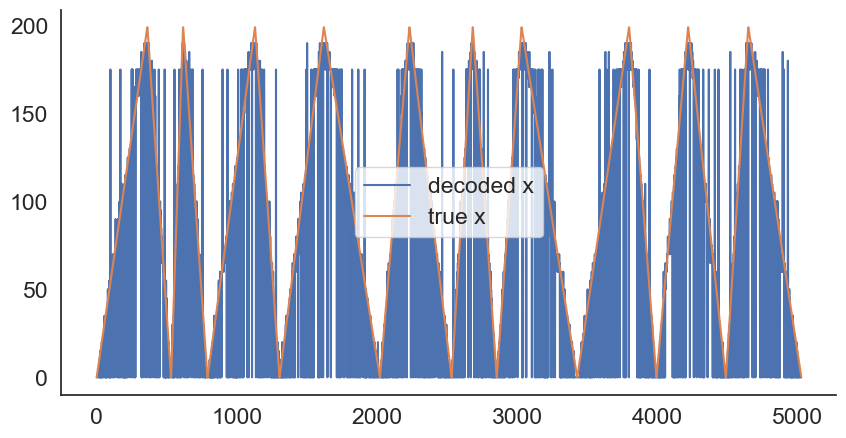

In [73]:
plt.figure(figsize=(10,5))
# plt.subplot(1,2,1)
plt.plot(x_decoded,label= 'decoded x')
plt.plot(true_x,label = 'true x')
plt.legend()
# plt.subplot(1,2,2)
# plt.plot(x_decoded_orig,label= 'decoded x')
# plt.plot(true_x,label = 'true x')
# plt.legend()

Median error: 6.407201828099659 cm


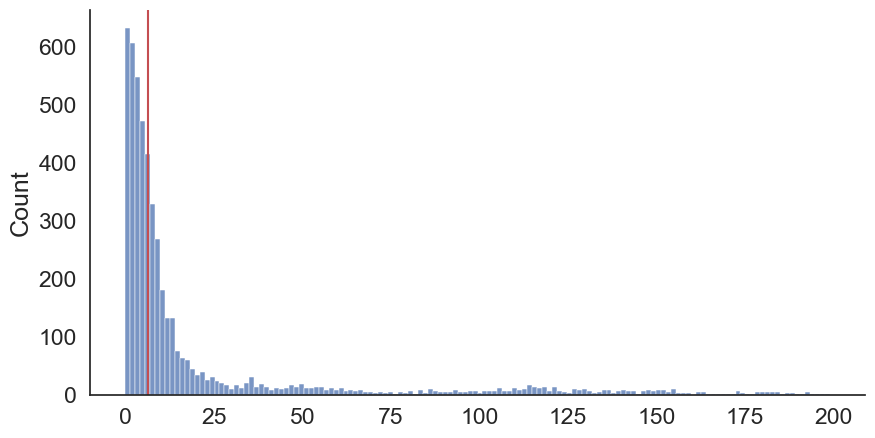

In [74]:
# error distribution
mse = np.sqrt((true_x-x_decoded)**2)
sns.histplot(mse)
plt.axvline(x = np.nanmedian(mse),c='r')
print(f'Median error: {np.nanmedian(mse)} cm')

In [75]:
# code decoding
from scipy.stats import poisson

true_x = x[:-1] # get rid of last timepoint to have same length as binned spikes
decoding_times = t[:-1]

x_decoded = np.zeros_like(true_x)

for t_bin in tqdm(range(len(decoding_times))):
    if sum(spikes_count[t_bin,:])>0: # Check if the time window contains spikes
        posterior = np.empty(firing_rate_maps.shape[-1])

        for i in range(len(posterior)):
            # Note that we work with log so that we can sum probabilities
            # instead of multiplying them 
            posterior[i] = sum(np.log(poisson.pmf(spikes_count[t_bin,:],firing_rate_maps[:,i]/fps)+pow(10,-15))) # mistake lies in the pow function setting
            #posterior[i] = sum(poisson.logpmf(spikes_count[t_bin,:],firing_rate_maps[:,i]/fps)+pow(10,-15))


        x_decoded[t_bin] = space_bins[np.argmax(posterior)]
        
    else:
        x_decoded[t_bin] = np.nan


100%|██████████| 5026/5026 [00:17<00:00, 289.80it/s]


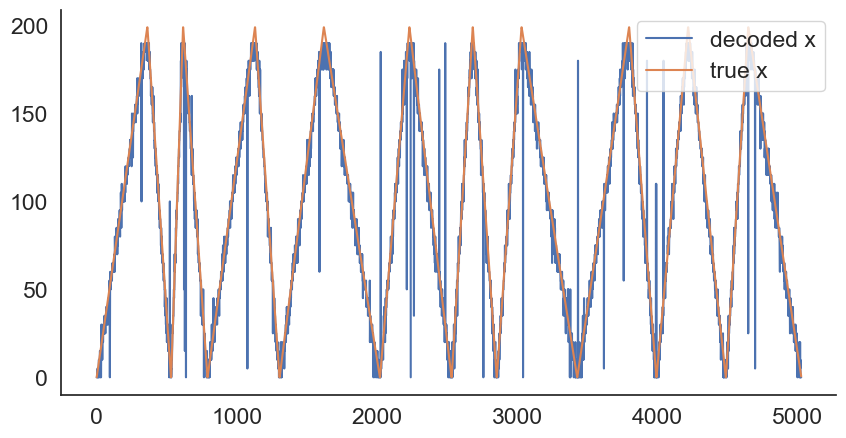

In [76]:
plt.figure(figsize=(10,5))
# plt.subplot(1,2,1)
plt.plot(x_decoded,label= 'decoded x')
plt.plot(true_x,label = 'true x')
plt.legend()

Median error: 3.357155002380459 cm


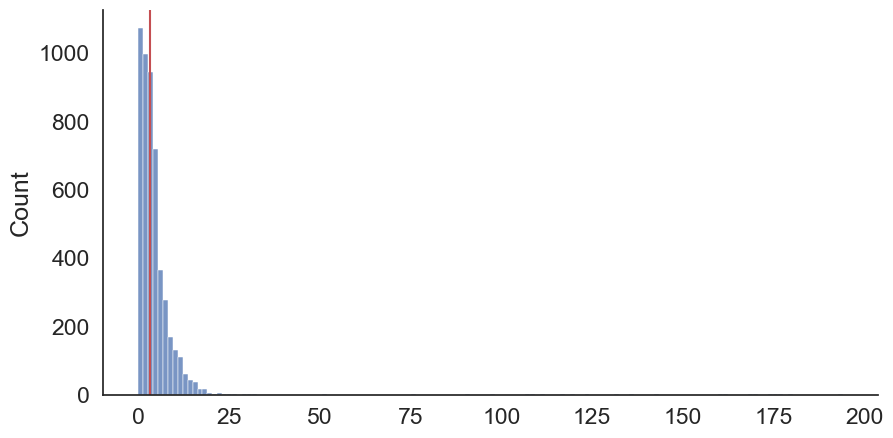

In [77]:
# error distribution
mse = np.sqrt((true_x-x_decoded)**2)
sns.histplot(mse)
plt.axvline(x = np.nanmedian(mse),c='r')
print(f'Median error: {np.nanmedian(mse)} cm')

The median error has increased to 6.41 cm, The shape of the distribution has also changed. It seems to have a longer right-tail and a much diminished maximum count (the previous plot showed counts of upward 1000 for the lower values on the x-axis whereas this plot only just gets above 600 counts).
it is due to the setting of pow(10, -15) --> this was first written as pow(1,-15) which means a smaller tolerance is given to the logarithm which causes diverging computations
When setting this to the same value as for the other line the results are near identical to the other run (media error becomes 3.36)



## Exercise 3
---
A - Estimate the quality of the sequence detection methods we saw in the lesson. How many false poistive does it find? How many false negatives?

B - Investigate the effect of `noise_x_react` and `noise_t_react` on the false positive rate and the false negative rate of our detection procedure.

C - What kind of sequence can our methods detect? What kind of activity, despide being sequential, could escape our detection method? Would you have an idea for a different method for sequence detection?
